In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
columns = [
    'unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
    'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd',
    'PCNfR_dmd', 'W31', 'W32'
]

In [3]:
datasets = ['FD001', 'FD002', 'FD003', 'FD004']
all_train, all_test = [], []
offset = 0

In [ ]:
for fd in datasets:
    df_tr = pd.read_csv(f'CMaps/train_{fd}.txt', sep=r'\s+', header=None, names=columns)
    df_te = pd.read_csv(f'CMaps/test_{fd}.txt', sep=r'\s+', header=None, names=columns)
    rul = pd.read_csv(f'CMaps/RUL_{fd}.txt', sep=r'\s+', header=None).values.flatten()
    
   
    df_tr['unit_number'] += offset
    df_te['unit_number'] += offset
    
    eol_tr = df_tr.groupby('unit_number')['time_in_cycles'].transform('max')
    df_tr['EOL'] = eol_tr
    df_tr['RUL'] = eol_tr - df_tr['time_in_cycles']
    

    eol_te = []
    for eng in df_te['unit_number']:
        cycles_run = len(df_te[df_te['unit_number'] == eng])
        actual_rul = rul[(eng - offset) - 1]
        eol_te.append(cycles_run + actual_rul)
    df_te['EOL'] = eol_te
    df_te['RUL'] = df_te['EOL'] - df_te['time_in_cycles']
    
    all_train.append(df_tr)
    all_test.append(df_te)
    offset += 1000

In [5]:

mega_train_df = pd.concat(all_train, ignore_index=True)
mega_test_df = pd.concat(all_test, ignore_index=True)
print(f"Stitched Training Set: {mega_train_df.shape[0]} rows")
print(f"Stitched Test Set    : {mega_test_df.shape[0]} rows")

Stitched Training Set: 160359 rows
Stitched Test Set    : 104897 rows


In [6]:
def assign_labels_and_drop(df):
    df['LR'] = df['time_in_cycles'] / df['EOL']
    labels = []
    for lr in df['LR']:
        if lr <= 0.6: labels.append(0)
        elif lr <= 0.8: labels.append(1)
        else: labels.append(2)
    df['label'] = labels
   
    return df.drop(columns=['unit_number', 'EOL', 'LR'])

mega_train = assign_labels_and_drop(mega_train_df)
mega_test = assign_labels_and_drop(mega_test_df)

In [ ]:

flatline_cols = mega_train.columns[mega_train.std() < 0.01]
print("Dropped flatline features:", list(flatline_cols))

mega_train = mega_train.drop(columns=flatline_cols)
mega_test = mega_test.drop(columns=flatline_cols, errors='ignore')

Dropped flatline features: ['farB']


In [8]:
X_train_raw = mega_train.drop(columns=['label', 'RUL'])
y_train_class = mega_train['label']
y_train_reg = mega_train['RUL'].clip(upper=125)

X_test_raw = mega_test.drop(columns=['label', 'RUL'])
y_test_class = mega_test['label']
y_test_reg = mega_test['RUL'].clip(upper=125)

In [9]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)


In [10]:
print("Final expected features count:", X_train_raw.shape[1])
print("Features list:", X_train_raw.columns.tolist())

Final expected features count: 24
Features list: ['time_in_cycles', 'setting_1', 'setting_2', 'TRA', 'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']


In [ ]:

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train_scaled, y_train_class)

🌲 Training RandomForest Classifier on Mega-Dataset...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:

y_pred_class = rf_classifier.predict(X_test_scaled)
print("=== MEGA CLASSIFIER EVALUATION ===")
print(f"Test Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class, target_names=['Good (0)', 'Warning (1)', 'Critical (2)']))

=== MEGA CLASSIFIER EVALUATION ===
Test Accuracy: 0.9079

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.96      0.95      0.95     84883
 Warning (1)       0.66      0.72      0.69     14791
Critical (2)       0.80      0.82      0.81      5223

    accuracy                           0.91    104897
   macro avg       0.81      0.83      0.82    104897
weighted avg       0.91      0.91      0.91    104897



In [ ]:

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train_scaled, y_train_reg)

🌲 Training RandomForest Regressor on Mega-Dataset...


RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:

y_pred_reg = rf_regressor.predict(X_test_scaled)
print("=== MEGA REGRESSOR EVALUATION ===")
print(f"Test MAE : {mean_absolute_error(y_test_reg, y_pred_reg):.4f} cycles")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f} cycles")
print(f"Test R2  : {r2_score(y_test_reg, y_pred_reg):.4f}")

=== MEGA REGRESSOR EVALUATION ===
Test MAE : 9.6784 cycles
Test RMSE: 15.4362 cycles
Test R2  : 0.6698


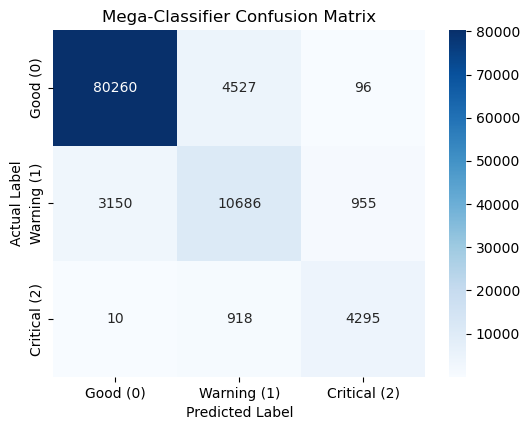

In [ ]:

cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good (0)', 'Warning (1)', 'Critical (2)'], 
            yticklabels=['Good (0)', 'Warning (1)', 'Critical (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Mega-Classifier Confusion Matrix')
plt.show()

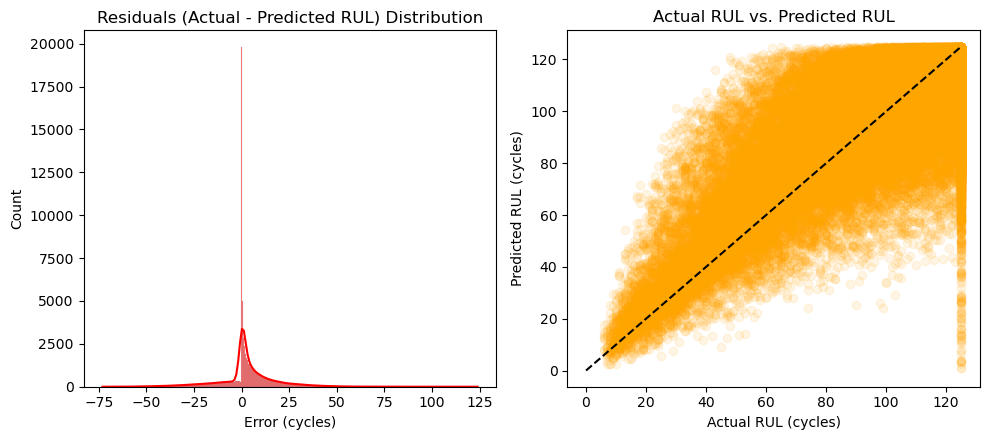

In [ ]:

plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
sns.histplot(y_test_reg - y_pred_reg, kde=True, color='red')
plt.title('Residuals (Actual - Predicted RUL) Distribution')
plt.xlabel('Error (cycles)')

plt.subplot(1, 2, 2)
plt.scatter(y_test_reg, y_pred_reg, alpha=0.1, color='orange')
plt.plot([0, 125], [0, 125], '--k')
plt.title('Actual RUL vs. Predicted RUL')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')

plt.tight_layout()
plt.show()